1. Wczytanie danych
2. Podzial danych na cechy i etykiety
3. Trenowanie i przewidywanie modelu Random Forest
Work time:  112.48185873031616 s
4. Ocena modelu
Confusion Matrix:
[[55254 27533]
 [    1 57756]]


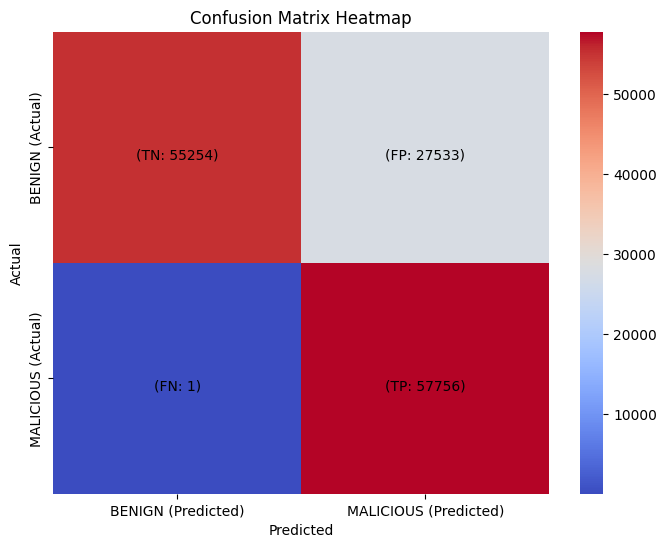

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.67      0.80     82787
   MALICIOUS       0.68      1.00      0.81     57757

    accuracy                           0.80    140544
   macro avg       0.84      0.83      0.80    140544
weighted avg       0.87      0.80      0.80    140544



In [ ]:
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import warnings
warnings.filterwarnings("ignore")


print("1. Wczytanie danych")
# day = 'Monday'
# day = 'Tuesday'
# day = 'Wednesday'
# day = 'Thursday'
day = 'Friday'
processed_filepath = './datasets/processed/'
data = pd.read_csv(processed_filepath + f'{day}.csv')
df = data.copy()

print("2. Podzial danych na cechy i etykiety")
X = df.iloc[:, :-1].values  # Wszystkie kolumny oprócz ostatniej (cechy)
y = df.iloc[:, -1].values   # Ostatnia kolumna (etykiety)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. Trenowanie i przewidywanie modelu Random Forest")
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight={0: 0.001, 1: 100000})

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

end_time = time.time() 
print("Work time: ", end_time - start_time, "s")

print("4. Ocena modelu")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='coolwarm', 
                 xticklabels=['BENIGN (Predicted)', 'MALICIOUS (Predicted)'], 
                 yticklabels=['BENIGN (Actual)', 'MALICIOUS (Actual)'])

labels = [[f'TN: {cm[0][0]}', f'FP: {cm[0][1]}'], 
          [f'FN: {cm[1][0]}', f'TP: {cm[1][1]}']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f'\n({labels[i][j]})', 
                color='Black', ha='center', va='center', fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

results_dir = './results/RF/'
os.makedirs(results_dir, exist_ok=True)
results_filepath = results_dir + f'RF_{day}_model_results.txt'

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'MALICIOUS']))
report = classification_report(y_test, y_pred, target_names=['BENIGN', 'MALICIOUS'])
with open(f'{results_dir}Classification_Report_RF_{day}.txt', 'w') as f:
    f.write(report)

In [54]:
import numpy as np
import os

TN, FP = cm[0]
FN, TP = cm[1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [55]:
results_dir = './results/RF/'
os.makedirs(results_dir, exist_ok=True)
results_filepath = results_dir + f'RF_{day}_model_results.txt'

with open(results_filepath, 'w') as f:
    f.write("==========================================================================================\n")
    f.write("===\n")
    f.write(f"{results_filepath}\n")
    f.write("===\n")
    f.write(f"Czas uczenia: {end_time - start_time:.2f} s\n")
    f.write(f"Macierz konfuzji:\n")
    f.write(f"[[ True Negatives (TN): {cm[0][0]}   False Positives (FP): {cm[0][1]} ]\n")
    f.write(f" [ False Negatives (FN): {cm[1][0]}   True Positives (TP): {cm[1][1]} ]]\n\n")
    f.write(f"Accuracy: {accuracy:.2%}\n")
    f.write(f"Precision (dla klasy ATTACK): {precision:.2%}\n")
    f.write(f"Recall (dla klasy ATTACK): {recall:.2%}\n")
    f.write(f"F1-score: {f1_score:.2%}\n")
    f.write("==========================================================================================\n")

In [56]:
y_pred_probs = rf_model.predict_proba(X_test)[:, 1]

# Zmodyfikuj funkcje w komórce ffeab539
def make_roc_plot():
    from sklearn.metrics import roc_curve, auc

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
    plt.title('RF: ROC Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend()
    plt.grid()
    # Zapisz wykres do pliku
    plt.savefig(f'{results_dir}ROC_curve_RF_{day}.png')
    plt.close()  # Zamknij wykres zamiast pokazywać

def make_precission_recall_plot():
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
    average_precision = average_precision_score(y_test, y_pred_probs)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
    plt.title('RF: Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    # Zapisz wykres do pliku
    plt.savefig(f'{results_dir}Precision_Recall_curve_RF_{day}.png')
    plt.close()  # Zamknij wykres zamiast pokazywać

make_precission_recall_plot()
make_roc_plot()